In [ ]:

# 1 env setup

!pip install kagglehub pandas matplotlib seaborn plotly wordcloud

import kagglehub
import pandas as pd
import numpy as np

# fetching the raw Netflix dataset
path = kagglehub.dataset_download("shivamb/netflix-shows")
print("Dataset downloaded to:", path)

# loading into standard pandas dataframe
df = pd.read_csv(f"{path}/netflix_titles.csv")
print(f"Successfully loaded dataset. Shape: {df.shape}")


# 2 data engineering


# task a: the duration fix

df['duration_minutes'] = df.apply(
    lambda row: int(row['duration'].split()[0]) if pd.notnull(row['duration']) and 'min' in str(row['duration']) else np.nan,
    axis=1
)
df['duration_seasons'] = df.apply(
    lambda row: int(row['duration'].split()[0]) if pd.notnull(row['duration']) and 'Season' in str(row['duration']) else np.nan,
    axis=1
)

# task b: datetime parsing

df['date_added_clean'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')

# extracting key temporal components for trend exploration
df['added_year'] = df['date_added_clean'].dt.year
df['added_month'] = df['date_added_clean'].dt.strftime('%B')
df['added_day_of_week'] = df['date_added_clean'].dt.strftime('%A')

# task c: handling arrays before Unnesting

array_cols = ['cast', 'director', 'country', 'listed_in']
for col in array_cols:
    df[col] = df[col].fillna('Unknown')

print("Data engineering complete. ready for visualization.")

Using Colab cache for faster access to the 'netflix-shows' dataset.
Dataset downloaded to: /kaggle/input/netflix-shows
Successfully loaded dataset. Shape: (8807, 12)
Data Engineering Pipeline complete! Ready for Visualization.


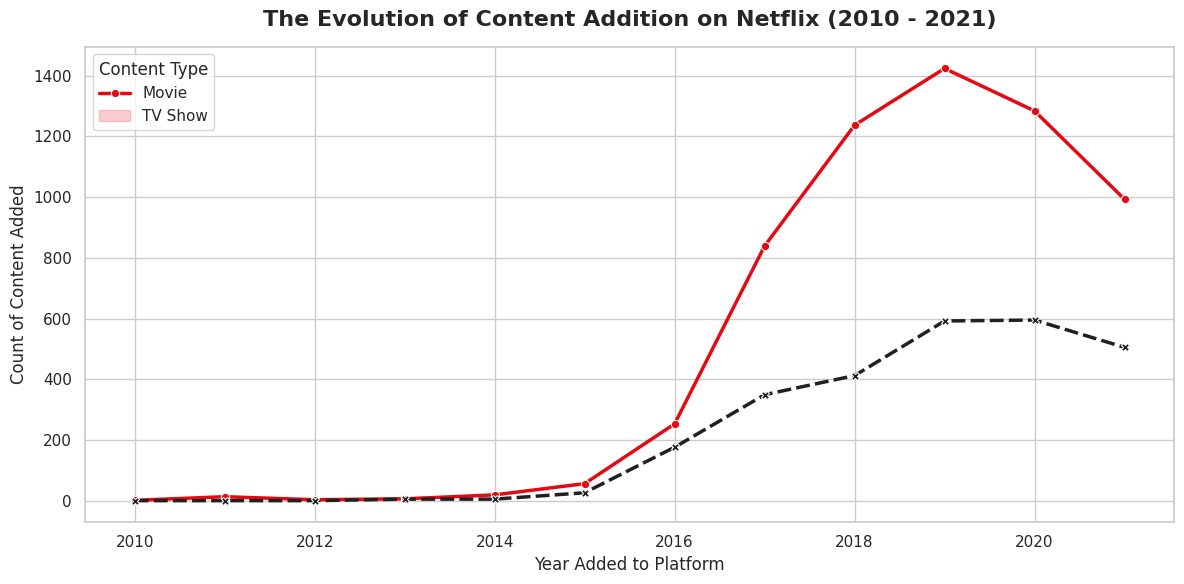

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# group data by content addition year and type
temporal_df = df.groupby(['added_year', 'type']).size().unstack().fillna(0)
# filter for years where significant data exists
temporal_df = temporal_df[temporal_df.index >= 2010]


sns.lineplot(data=temporal_df, palette=['#E50914', '#221F1F'], linewidth=2.5, markers=True)

plt.title('The Evolution of Content Addition on Netflix (2010 - 2021)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year Added to Platform', fontsize=12)
plt.ylabel('Count of Content Added', fontsize=12)
plt.legend(['Movie', 'TV Show'], title='Content Type', frameon=True)
plt.tight_layout()
plt.show()

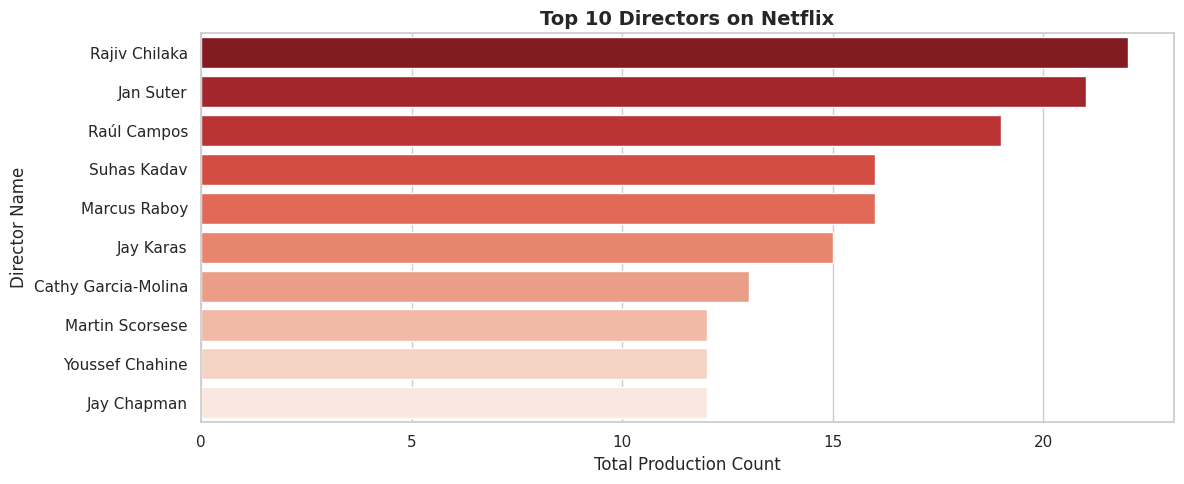

In [3]:
# create specific exploded dataframes for array analysis

df_exploded_cast = df[df['cast'] != 'Unknown'].copy()
df_exploded_cast['cast'] = df_exploded_cast['cast'].str.split(', ')
df_exploded_cast = df_exploded_cast.explode('cast')

df_exploded_dir = df[df['director'] != 'Unknown'].copy()
df_exploded_dir['director'] = df_exploded_dir['director'].str.split(', ')
df_exploded_dir = df_exploded_dir.explode('director')

# plotting the top 10 directors on netflix
plt.figure(figsize=(12, 5))
top_directors = df_exploded_dir['director'].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, palette='Reds_r', hue=top_directors.index, legend=False)

plt.title('Top 10 Directors on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Total Production Count')
plt.ylabel('Director Name')
plt.tight_layout()
plt.show()

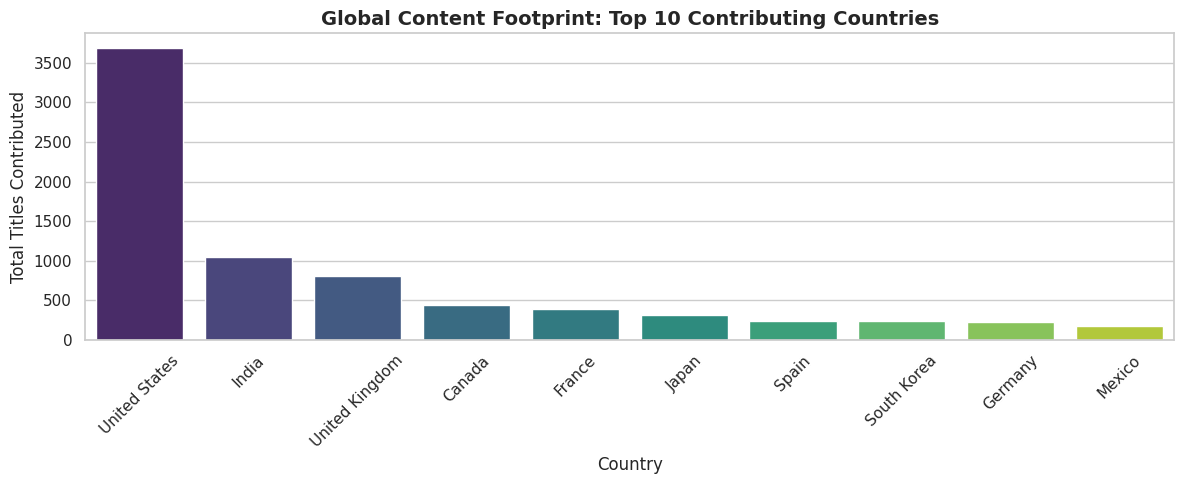

In [4]:
df_country = df[df['country'] != 'Unknown'].copy()
df_country['country'] = df_country['country'].str.split(', ')
df_country = df_country.explode('country')

plt.figure(figsize=(12, 5))
top_countries = df_country['country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis', hue=top_countries.index, legend=False)

plt.title('Global Content Footprint: Top 10 Contributing Countries', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Total Titles Contributed')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

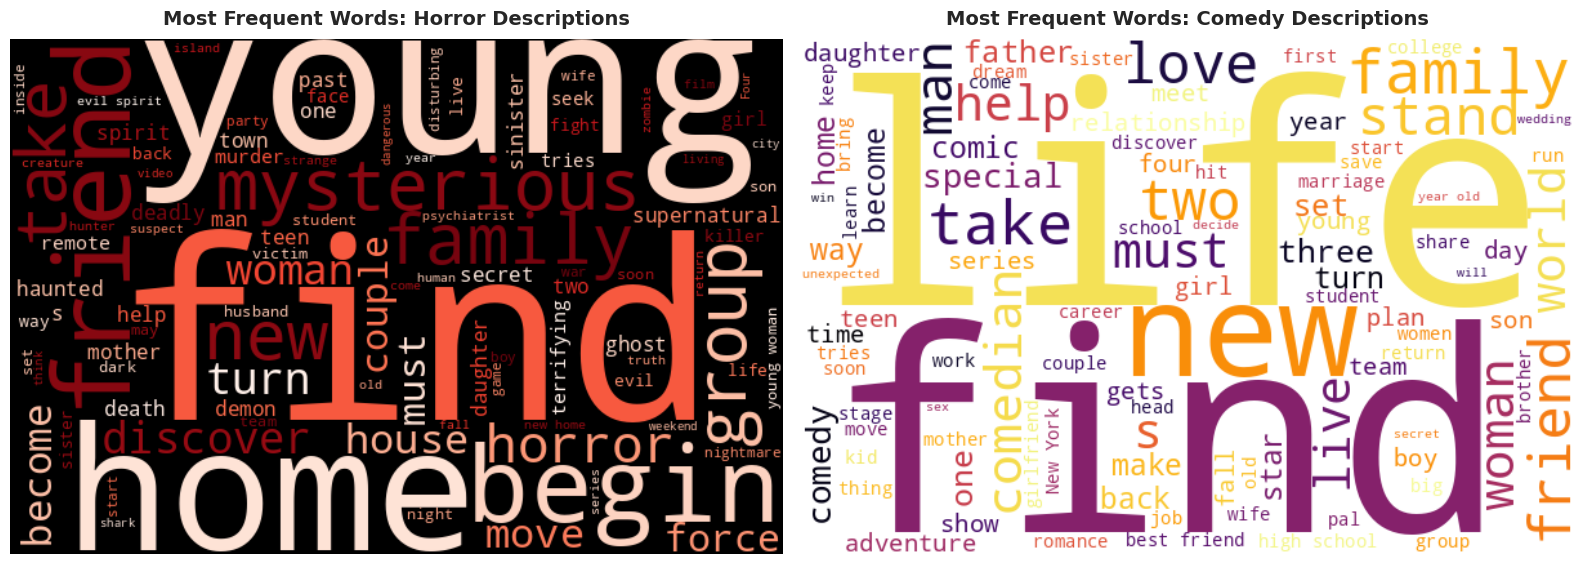

In [5]:
from wordcloud import WordCloud, STOPWORDS

# filtering descriptions for specific genres
horror_desc = " ".join(df[df['listed_in'].str.contains('Horror Movies|TV Horrors', case=False)]['description'].dropna())
comedy_desc = " ".join(df[df['listed_in'].str.contains('Comedies|Comedy', case=False)]['description'].dropna())


stopwords = set(STOPWORDS)

wc_horror = WordCloud(width=600, height=400, background_color='black', max_words=100, stopwords=stopwords, colormap='Reds').generate(horror_desc)
wc_comedy = WordCloud(width=600, height=400, background_color='white', max_words=100, stopwords=stopwords, colormap='inferno').generate(comedy_desc)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(wc_horror, interpolation='bilinear')
axes[0].set_title('Most Frequent Words: Horror Descriptions', fontsize=14, fontweight='bold', pad=10)
axes[0].axis('off')

axes[1].imshow(wc_comedy, interpolation='bilinear')
axes[1].set_title('Most Frequent Words: Comedy Descriptions', fontsize=14, fontweight='bold', pad=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()

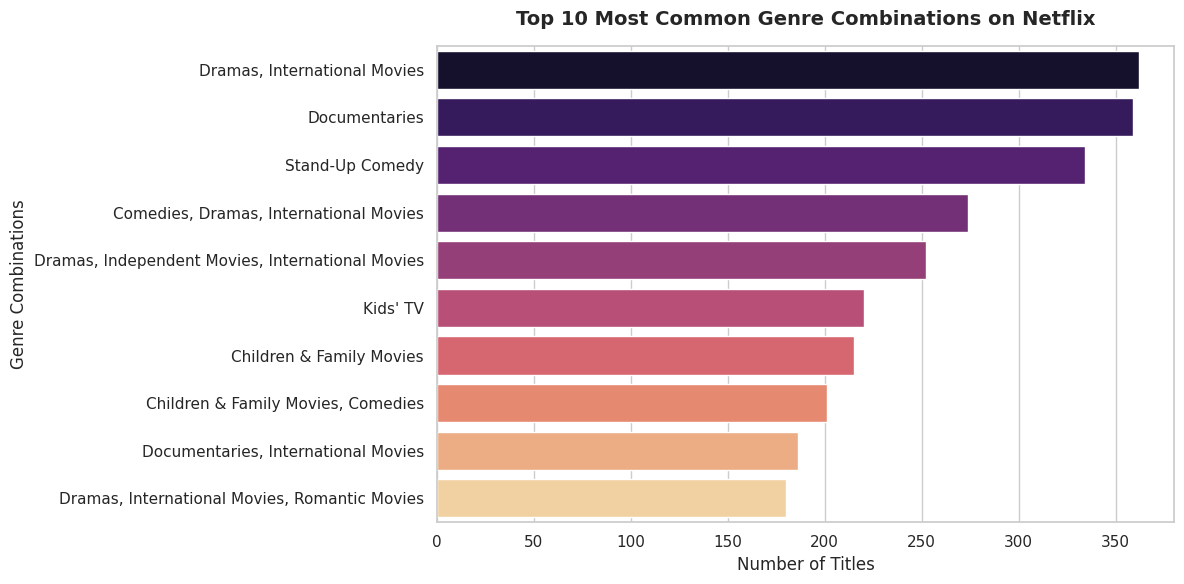

In [ ]:

# genre combination analysis

plt.figure(figsize=(12, 6))

# clean up any trailing spaces in the listed_in column strings
df['listed_in_clean'] = df['listed_in'].str.strip()

# top 10 most common combinations of genres
top_genre_combinations = df['listed_in_clean'].value_counts().head(10)

# plot the combinations
sns.barplot(
    x=top_genre_combinations.values,
    y=top_genre_combinations.index,
    palette='magma',
    hue=top_genre_combinations.index,
    legend=False
)


plt.title('Top 10 Most Common Genre Combinations on Netflix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre Combinations', fontsize=12)
plt.tight_layout()
plt.show()